In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', '^NSEBANK']
data = yf.download(tickers, period = "2y", auto_adjust=True)
data_dropped = data[~(data == 0).any(axis=1)].copy()
data_dropped = data_dropped[~data_dropped.isna().any(axis=1)].copy()
data_cleaned = data_dropped.copy()
data_cleaned['Volume'] = data_cleaned['Volume'].astype('float64').copy()

[*********************100%***********************]  3 of 3 completed


In [4]:
data_close = data_cleaned['Close'].copy()
returns = data_close.pct_change().dropna()

In [5]:
def beta(stock, index):
    matrix = np.cov(stock, index)
    return matrix[0, 1] / matrix[1, 1]

In [6]:
beta_hdfc = beta(returns["HDFCBANK.NS"], returns["^NSEBANK"])
beta_icici = beta(returns["ICICIBANK.NS"], returns["^NSEBANK"])

print(f"HDFC Bank Beta: {beta_hdfc:.3f}")
print(f"ICICI Bank Beta: {beta_icici:.3f}")

HDFC Bank Beta: 0.942
ICICI Bank Beta: 0.927


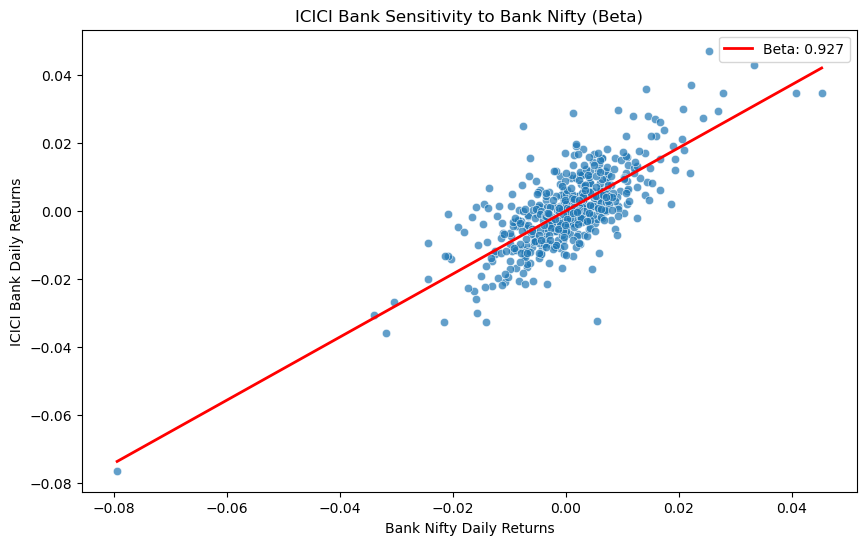

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="^NSEBANK", y="ICICIBANK.NS", linewidth=0.5, alpha=0.7, data=returns)

m, b = np.polyfit(returns['^NSEBANK'], returns['ICICIBANK.NS'], 1)
x = np.linspace(returns['^NSEBANK'].min(), returns['^NSEBANK'].max(), 100)
line = m*x + b

plt.plot(x, line, color='red', linewidth=2, label=f'Beta: {m:.3f}')

plt.title("ICICI Bank Sensitivity to Bank Nifty (Beta)")
plt.xlabel("Bank Nifty Daily Returns")
plt.ylabel("ICICI Bank Daily Returns")
plt.legend()
plt.show()

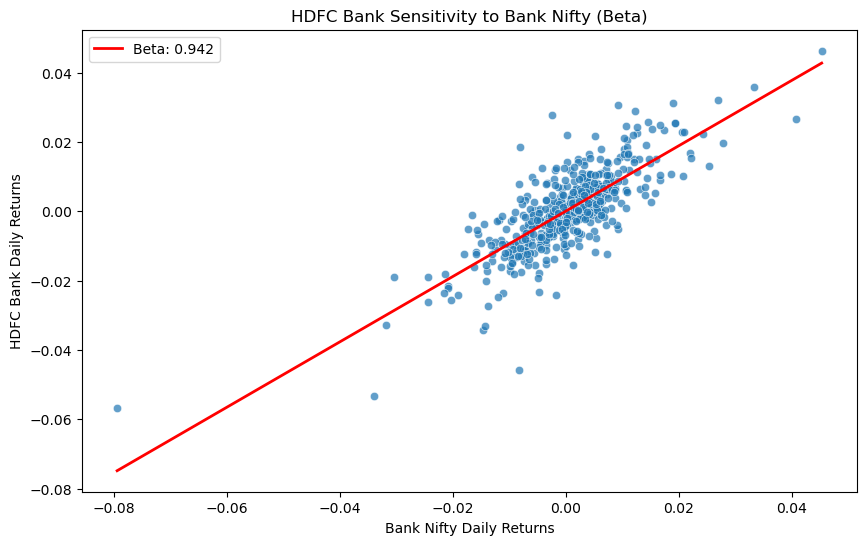

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="^NSEBANK", y="HDFCBANK.NS", linewidth=0.5, alpha=0.7, data=returns)

m, b = np.polyfit(returns['^NSEBANK'], returns['HDFCBANK.NS'], 1)
x = np.linspace(returns['^NSEBANK'].min(), returns['^NSEBANK'].max(), 100)
line = m*x + b

plt.plot(x, line, color='red', linewidth=2, label=f'Beta: {m:.3f}')

plt.title("HDFC Bank Sensitivity to Bank Nifty (Beta)")
plt.xlabel("Bank Nifty Daily Returns")
plt.ylabel("HDFC Bank Daily Returns")
plt.legend()
plt.show()